LINEAR MODEL EQUATION:
Temperature = 24.418236 * Voltage + -5.810502

ERROR METRICS:
MAE  = 7.293 °C
RMSE = 8.880 °C
R² Score = 0.999489


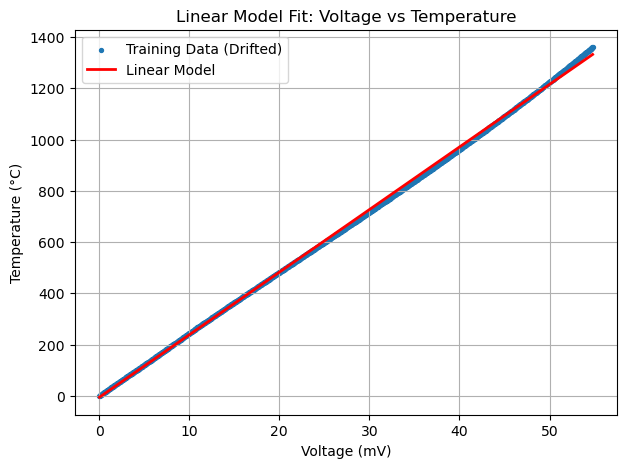

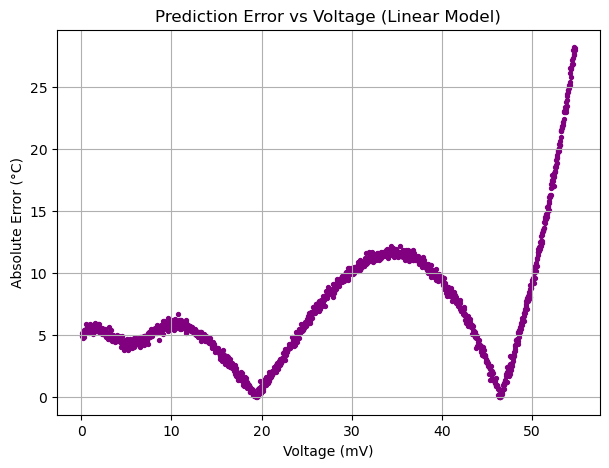


MANUAL CHECK (Voltage → Temperature)
0.039 mV → -4.86 °C
0.397 mV → 3.88 °C
48.838 mV → 1186.73 °C
43.518 mV → 1056.82 °C
45.119 mV → 1095.92 °C


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 1. Load dataset (UNCHANGED)
# -----------------------------
data = pd.read_csv("NIST Thermocouple Type K 2.csv")

temperature = data["Temperature"].values
ideal_voltage = data["Voltage"].values

# -----------------------------
# 2. Add drift (ONLY for training)
# -----------------------------
np.random.seed(42)

gain_drift = 0.005      # 0.5% gain drift
offset_drift = 0.03     # offset drift (mV)
noise = np.random.normal(0, 0.01, size=len(ideal_voltage))

drifted_voltage = ideal_voltage * (1 + gain_drift) + offset_drift + noise

X = drifted_voltage.reshape(-1, 1)   # Input: Voltage
y = temperature                      # Output: Temperature

# -----------------------------
# 3. Train LINEAR regression model
# -----------------------------
model = LinearRegression()
model.fit(X, y)

print("LINEAR MODEL EQUATION:")
print(f"Temperature = {model.coef_[0]:.6f} * Voltage + {model.intercept_:.6f}")

# -----------------------------
# 4. Model prediction
# -----------------------------
y_pred = model.predict(X)

# -----------------------------
# 5. ERROR METRICS
# -----------------------------
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("\nERROR METRICS:")
print(f"MAE  = {mae:.3f} °C")
print(f"RMSE = {rmse:.3f} °C")
print(f"R² Score = {r2:.6f}")

# -----------------------------
# 6. GRAPH 1: Model Fit
# -----------------------------
idx = np.argsort(X.flatten())
X_sorted = X[idx]
y_sorted = y[idx]
y_line = model.predict(X_sorted)

plt.figure(figsize=(7,5))
plt.scatter(X, y, s=8, label="Training Data (Drifted)")
plt.plot(X_sorted, y_line, color="red", linewidth=2, label="Linear Model")
plt.xlabel("Voltage (mV)")
plt.ylabel("Temperature (°C)")
plt.title("Linear Model Fit: Voltage vs Temperature")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 7. GRAPH 2: Prediction Error vs Voltage
# -----------------------------
error = np.abs(y - y_pred)

plt.figure(figsize=(7,5))
plt.scatter(X, error, s=8, color="purple")
plt.xlabel("Voltage (mV)")
plt.ylabel("Absolute Error (°C)")
plt.title("Prediction Error vs Voltage (Linear Model)")
plt.grid(True)
plt.show()

# -----------------------------
# 8. MANUAL CHECK (ONLY VOLTAGE INPUT)
# -----------------------------
print("\nMANUAL CHECK (Voltage → Temperature)")

manual_voltages = np.array([
    [0.039],    # ~1°C
    [0.397],    # ~10°C
    [48.838],   # ~1200°C
    [43.518],   # ~1058°C
    [45.119]    # ~1100°C
])

manual_pred = model.predict(manual_voltages)

for v, t in zip(manual_voltages.flatten(), manual_pred):
    print(f"{v:.3f} mV → {t:.2f} °C")